In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.visualization import make_rgb, AsinhStretch
from torchvision.transforms import ToPILImage

# load galaxy dataset

In [2]:
from galaxy_datasets import gz_candels 

catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [3]:
cols = catalog.columns.to_numpy()

# initial testing

In [4]:
from ml_sandbox.dataset import load_image
import numpy as np
im = load_image(catalog['filename'][0], dir='.tmp/')


In [5]:
import torch

In [6]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
import torch
# gzdataset = GalaxyDataset(
#     catalog,
#     label_cols=['merging-candels_merger'],  
#     # transform=ToTensor(),
#     target_transform=lambda x: torch.tensor(x, dtype=torch.float32),
#     )

In [7]:
from ml_sandbox.dataset import get_dataset
dataset_tr = get_dataset(catalog, label_cols=['merging-candels_merger'], size=1000, train=True, dir='.tmp/')

In [8]:
for i in range(10):
    img, label = dataset_tr[i]
    print(f"Max value: {img.max()}, Min value: {img.min()}")

Max value: 0.9173336029052734, Min value: 0.0005210505332797766
Max value: 0.609416663646698, Min value: 0.0009022970334626734
Max value: 0.9065151214599609, Min value: 0.0015941649908199906
Max value: 0.5341896414756775, Min value: 7.495579666283447e-06
Max value: 0.34593501687049866, Min value: 0.0
Max value: 0.5963096022605896, Min value: 0.00010948856652248651
Max value: 0.2835302948951721, Min value: 0.0
Max value: 0.3235926330089569, Min value: 6.0753650359401945e-06
Max value: 0.6581758856773376, Min value: 0.0
Max value: 0.9742690920829773, Min value: 0.0010250818450003862


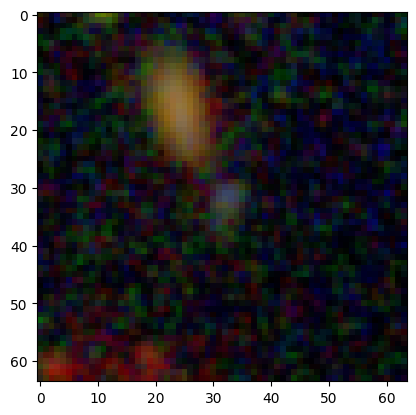

In [9]:
im, lab = dataset_tr[5]
plt.imshow(im.permute(1,2,0))

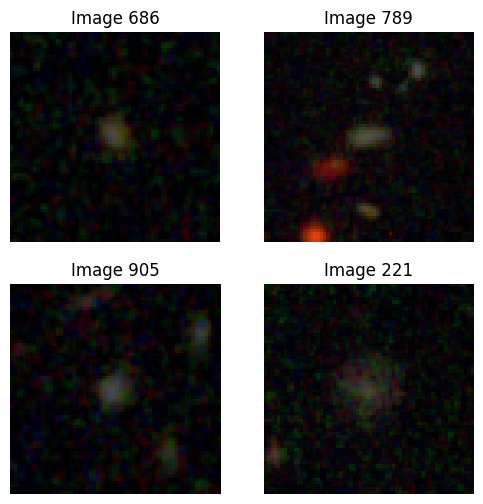

In [10]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(dataset_tr, num_images=i+1)

# training

In [11]:
catalog['merging-candels_merger'].max()+1

np.float64(59.0)

In [12]:
from ml_sandbox.models import SimpleCNNClassifier
from ml_sandbox.train_eval import train_cnn, test_cnn
from ml_sandbox.dataset import get_dataloader
from sklearn.model_selection import train_test_split

model = SimpleCNNClassifier(num_classes=int(catalog['merging-candels_merger'].max()+1), input_channels=3)

train_cat, test_cat = train_test_split(catalog, test_size=0.2, random_state=42)

train_dataset = get_dataset(train_cat, label_cols=['merging-candels_merger'], size=None, train=True, dir='.tmp/')
test_dataset = get_dataset(test_cat, label_cols=['merging-candels_merger'], size=None, train=False, dir='.tmp/')

train_loader = get_dataloader(train_dataset, batch_size=8)
test_loader = get_dataloader(test_dataset, batch_size=8)

from torch.nn import CrossEntropyLoss
criterion = CrossEntropyLoss()

from torch.optim import Adam
optimizer = Adam(model.parameters(), lr=1e-3)

In [13]:
for images, labels in train_loader:
    print(images.shape, labels.shape)
    print(labels.dim())
    break

torch.Size([8, 3, 64, 64]) torch.Size([8])
1


In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model=model.to(device)
device

device(type='cuda')

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for i in range(5):
    train_loss, train_acc = train_cnn(train_loader, model, criterion, optimizer, device=device) 
    test_loss, test_acc = test_cnn(test_loader, model, criterion, device=device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    print(f"Epoch: {i+1}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

loss: 2.063522  [    8/31712]
loss: 2.237227  [  808/31712]
loss: 2.427240  [ 1608/31712]
loss: 2.768200  [ 2408/31712]
loss: 1.840677  [ 3208/31712]
loss: 2.060674  [ 4008/31712]
loss: 2.363075  [ 4808/31712]
loss: 2.636912  [ 5608/31712]
loss: 2.306934  [ 6408/31712]
loss: 2.348419  [ 7208/31712]
loss: 2.317853  [ 8008/31712]
loss: 2.884288  [ 8808/31712]
loss: 1.509357  [ 9608/31712]
loss: 2.530440  [10408/31712]
loss: 3.496639  [11208/31712]
loss: 2.897668  [12008/31712]
loss: 1.497863  [12808/31712]
loss: 2.352880  [13608/31712]
loss: 2.424989  [14408/31712]
loss: 1.823860  [15208/31712]
loss: 2.211272  [16008/31712]
loss: 1.927193  [16808/31712]
loss: 2.020361  [17608/31712]
loss: 2.635022  [18408/31712]
loss: 2.696218  [19208/31712]
loss: 2.314961  [20008/31712]
loss: 1.857826  [20808/31712]
loss: 3.422229  [21608/31712]
loss: 2.585218  [22408/31712]
loss: 2.413888  [23208/31712]
loss: 1.806264  [24008/31712]
loss: 3.055340  [24808/31712]
loss: 2.305977  [25608/31712]
loss: 2.01

In [17]:
history

{'train_loss': [2.2313133894675437],
 'train_acc': [0.2536263874873865],
 'test_loss': [2.1691167224799432],
 'test_acc': [0.26585950308992307]}

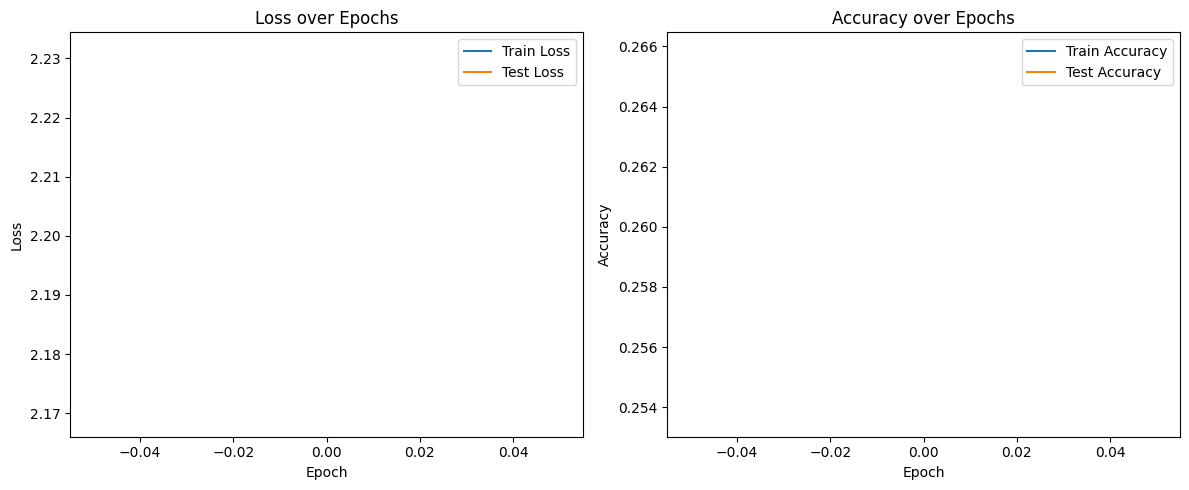

In [16]:
from ml_sandbox.train_eval import plot_training_history
plot_training_history(history)

In [7]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [ ]:
from ml_sandbox.dataset import convert_dataset_sklearn

X_train, y_train = convert_dataset_sklearn(train_dataset)
X_test, y_test = convert_dataset_sklearn(test_dataset)



In [ ]:
model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'